In [1]:
import os
# import jax
import numpy as np
import torch
# import torchtext
# import torchvision
# import torchvision.transforms as transforms
# from datasets import DatasetDict, load_dataset
from torch.utils.data import TensorDataset, random_split, DataLoader
from tqdm import tqdm

Example 1: sine waves are not just random squiggly lines; they are the fundamental "answers" to specific physics problems described by differential equations.

- The Equation (The Rule): An ODE describes how something changes, not where it is.
    - Example: "My speed is always proportional to my distance from home, but in the opposite direction."

    - Mathematically: y' =−y. (Acceleration is opposite to position).
    - The Solution (The Path): A solution is a specific function y(t) that obeys that rule at every single point in time.
    - If you plug y=sin(t) into that equation, it works perfectly. Therefore, the sine wave is the "solution."
    - Exact Solution: A clean mathematical formula (like y=sin(t)) that fits the rule perfectly with zero error.
    - Approximate Solution: When an equation is too hard to solve with a formula, computers calculate the path step-by-step (e.g., "If I'm here now, I'll be there in 0.1 seconds"). The result is a list of numbers that roughly follows the true curve.
    - in code Exact Solution first (using np.sin), but then you purposely degraded it into an Approximation (using np.digitize). Your dataset is a "low-resolution approximation" of the perfect mathematical solution.

- The Spring System (Simple Harmonic Motion) y+ω^2 y=0
- 

## Data

In [2]:
import os
import pandas as pd
# read the data for PVOD
abs_path = os.path.abspath("../PVODdatasets_v1")
metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)

In [3]:
print(f"All Avaiable Stations: {list(metaData['Station_ID'].unique())}")

All Avaiable Stations: ['station00', 'station01', 'station02', 'station03', 'station04', 'station05', 'station06', 'station07', 'station08', 'station09']


In [4]:
def get_station_metadata(station_num, df):
    """
    Retrieves metadata for a specific station number.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe (metaData).
        
    Returns:
        dict: A dictionary containing all processed metadata for the station.
    """
    
    # 1. Format the station ID (e.g., 5 -> 'station05')
    # zfill(2) ensures '5' becomes '05', but leaves '10' as '10'
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    # Check if station exists to prevent errors
    if station_row.empty:
        return f"Error: Station ID {station_id_str} not found."
    
    # Get the single row as a Series for easy access
    row = station_row.iloc[0]

    # --- Helper to parse the "Key:Value\nKey:Value" strings ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # 3. Parse complex columns
    module_items = parse_kv_string(row['Module'])
    inverter_items = parse_kv_string(row['Inverters'])

    # 4. Build the final dictionary
    # Note: We use .get() for the parsed items to safely handle missing keys
    result_dict = {
        'Station_ID': station_id_str, # Added ID for reference
        'Capacity': row['Capacity'],
        'pv_tech': row['PV_Technology'],
        'Panel_Size': row['Panel_Size'],
        
        # Parsed Module Items
        'Module_Pmax': module_items.get('Pmax'),
        'Module_Vmpp': module_items.get('Vmpp'),
        'Module_Impp': module_items.get('Impp'),
        
        # Parsed Inverter Items
        'Inverter_Max_DC_input': inverter_items.get('Max. DC input'),
        'Inverter_Max_DC_voltage': inverter_items.get('Max. DC voltage'),
        'Inverter_Max_DC_current': inverter_items.get('Max. DC current'),
        'Inverter_Max_DC_Rated_power': inverter_items.get('Rated power'),
        
        'Layout': row['Layout'],
        'Panel_Number': row['Panel_Number'],
        'Array_Tilt': row['Array_Tilt'],
        'Longitude': row['Longitude'],
        'Latitude': row['Latitude']
    }
    
    return result_dict

In [5]:
station05_metaData = get_station_metadata(5, metaData)

In [6]:
station05_metaData

{'Station_ID': 'station05',
 'Capacity': np.int64(35000),
 'pv_tech': 'Poly-Si',
 'Panel_Size': np.float64(1.63515),
 'Module_Pmax': '305 Wp',
 'Module_Vmpp': '31.13 V',
 'Module_Impp': '9.49 A',
 'Inverter_Max_DC_input': '618 kW',
 'Inverter_Max_DC_voltage': '1100 V',
 'Inverter_Max_DC_current': '1356 A',
 'Inverter_Max_DC_Rated_power': '1250 kW',
 'Layout': 'modules per string:22\nstrings per inverter:160',
 'Panel_Number': np.int64(114972),
 'Array_Tilt': 'South 33°',
 'Longitude': np.float64(114.1236),
 'Latitude': np.float64(38.2355)}

In [7]:
station05_path = os.path.join(abs_path, "station05.csv")
station05_data = pd.read_csv(station05_path)

In [8]:
station05_data.columns

Index(['date_time', 'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature',
       'nwp_humidity', 'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure',
       'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power'],
      dtype='object')

In [9]:
station05_data.head()

,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power
0,2019-03-04 16:00:00,0.0,0.0,8.94,49.55,2.63,291.41,993.26,0,0,9.8,991.900024,231,0.6,0.0
1,2019-03-04 16:15:00,0.0,0.0,8.70,50.05,2.69,286.85,993.10,0,0,9.1,991.799988,153,0.6,0.0
2,2019-03-04 16:30:00,0.0,0.0,8.49,50.47,2.75,282.10,993.12,0,0,9.3,991.900024,154,0.7,0.0
3,2019-03-04 16:45:00,0.0,0.0,8.33,50.76,2.80,276.14,993.18,0,0,9.1,991.700012,156,0.5,0.0
4,2019-03-04 17:00:00,0.0,0.0,8.22,50.91,2.86,267.24,993.30,0,0,9.5,991.799988,175,0.8,0.0


In [ ]:



import pandas as pd
import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re
import numpy as np

def calculate_clearsky_index(metadata, df):
    """
    Calculates Clear Sky Power (P_CLR) and PV Clear Sky Index (K_PV).
    Scales the simulation to the full station capacity and handles DataFrame outputs safely.
    """
    
    # ---------------------------------------------------------
    # 1. PARSE METADATA
    # ---------------------------------------------------------
    station_id = metadata.get('Station_ID', 'Unknown')
    print(f"Processing Station: {station_id}")
    
    def extract_num(s):
        if isinstance(s, (int, float)): return float(s)
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(s))
        return float(match.group()) if match else 0.0

    # Parse Layout
    layout_str = metadata.get('Layout', '')
    mod_per_string = 20 # default
    str_per_inv = 100   # default
    
    if 'modules per string' in layout_str:
        try:
            mod_per_string = int(extract_num(layout_str.split('modules per string:')[1].split('\n')[0]))
            str_per_inv = int(extract_num(layout_str.split('strings per inverter:')[1]))
        except:
            print("Warning: Could not parse Layout string, using defaults.")

    # Parse Tilt & Azimuth
    tilt_str = metadata.get('Array_Tilt', 'South 30')
    tilt = extract_num(tilt_str)
    
    azimuth = 180 
    if 'North' in tilt_str: azimuth = 0
    elif 'East' in tilt_str: azimuth = 90
    elif 'West' in tilt_str: azimuth = 270

    # ---------------------------------------------------------
    # 2. SETUP LOCATION & WEATHER
    # ---------------------------------------------------------
    # Copy df to avoid SettingWithCopy warnings on the original
    df = df.copy()
    
    if 'date_time' in df.columns:
        df = df.set_index('date_time')
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
    # Handle duplicates
    if df.index.duplicated().any():
        df = df[~df.index.duplicated(keep='first')]

    lat = metadata.get('Latitude', 38.0)
    lon = metadata.get('Longitude', 114.0)
    
    site_location = location.Location(lat, lon, tz='UTC') 

    print("Generating clear sky irradiance data...")
    clearsky_weather = site_location.get_clearsky(df.index, model='ineichen')

    # ---------------------------------------------------------
    # 3. DEFINE PV SYSTEM (Using PVWatts Inverter Model)
    # ---------------------------------------------------------
    temp_params = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

    # --- Module Parameters ---
    sandia_modules = pvsystem.retrieve_sam('SandiaMod')
    module_template = sandia_modules.columns[0]
    module_params = sandia_modules[module_template].copy()
    
    # Overwrite electrical specs from metadata
    module_params['Impo'] = extract_num(metadata.get('Module_Impp', 8.0))
    module_params['Vmpo'] = extract_num(metadata.get('Module_Vmpp', 30.0))
    module_params['Isco'] = module_params['Impo'] * 1.05 
    module_params['Voco'] = module_params['Vmpo'] * 1.2
    
    # --- Inverter Parameters & Scaling ---
    panel_watts = extract_num(metadata.get('Module_Pmax', 300))
    
    # DC Capacity of ONE inverter block (Watts)
    block_dc_capacity_watts = (mod_per_string * str_per_inv) * panel_watts
    
    # Station Total Capacity (Watts)
    station_capacity_watts = extract_num(metadata.get('Capacity', 0)) * 1000 
    
    # Calculate Scaling Factor (How many such blocks make up the station?)
    if block_dc_capacity_watts > 0 and station_capacity_watts > 0:
        scaling_factor = station_capacity_watts / block_dc_capacity_watts
    else:
        scaling_factor = 1.0
        
    print(f"Station Capacity: {station_capacity_watts/1e6:.2f} MW")
    print(f"Modeled Block Capacity: {block_dc_capacity_watts/1e6:.2f} MW")
    print(f"Scaling Factor: {scaling_factor:.2f}x")

    inverter_params = {
        'pdc0': block_dc_capacity_watts, 
        'eta_inv_nom': 0.96 
    }

    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_params,
        modules_per_string=mod_per_string,
        strings_per_inverter=str_per_inv,
        temperature_model_parameters=temp_params
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN
    # ---------------------------------------------------------
    mc = modelchain.ModelChain(
        system, 
        site_location,
        transposition_model="perez",
        solar_position_method="nrel_numpy",
        aoi_model="physical",
        spectral_model="no_loss",
        ac_model='pvwatts'
    )

    print("Running simulation...")
    try:
        mc.run_model(clearsky_weather)
    except Exception as e:
        print(f"Simulation failed: {e}")
        return df

    # ---------------------------------------------------------
    # 5. PROCESS RESULTS (Fixing ValueError)
    # ---------------------------------------------------------
    ac_output = mc.results.ac
    
    # FIX: Ensure output is a Series, summing if it's a DataFrame
    if isinstance(ac_output, pd.DataFrame):
        ac_output = ac_output.sum(axis=1)
        
    # Scale to full station capacity
    p_clr_watts = ac_output * scaling_factor
    
    # Convert to MW
    p_clr_mw = p_clr_watts / 1_000_000
    p_clr_mw = p_clr_mw.fillna(0).clip(lower=0)
    
    # Assign to DataFrame
    df['P_CLR'] = p_clr_mw
    
    # Calculate K_PV (Clear Sky Index)
    if 'power' in df.columns:
        # Filter small P_CLR values to avoid division by zero artifacts
        df['K_PV'] = np.where(df['P_CLR'] > 0.1, df['power'] / df['P_CLR'], 0.0)
    else:
        print("Warning: 'power' column not found. K_PV not calculated.")

    return df



station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)


# 3. Run Calculation
df_result = calculate_clearsky_index(station07_metaData, station07_data)

# 4. Inspect Results
print("\nResults Head:")
print(df_result[['power', 'P_CLR', 'K_PV']].head())

Processing Station: station07
Generating clear sky irradiance data...
Station Capacity: 20.00 MW
Modeled Block Capacity: 0.50 MW
Scaling Factor: 40.00x
Running simulation...

Results Head:
                     power  P_CLR  K_PV
date_time                              
2018-06-30 16:00:00    0.0    0.0   0.0
2018-06-30 16:15:00    0.0    0.0   0.0
2018-06-30 16:30:00    0.0    0.0   0.0
2018-06-30 16:45:00    0.0    0.0   0.0
2018-06-30 17:00:00    0.0    0.0   0.0


In [11]:
station07_metaData

{'Station_ID': 'station07',
 'Capacity': np.int64(20000),
 'pv_tech': 'Poly-Si',
 'Panel_Size': np.float64(1.6335),
 'Module_Pmax': '250 Wp',
 'Module_Vmpp': '29.8 V',
 'Module_Impp': '8.39 A',
 'Inverter_Max_DC_input': '618 kW',
 'Inverter_Max_DC_voltage': '1000 V',
 'Inverter_Max_DC_current': '1344 A',
 'Inverter_Max_DC_Rated_power': '500 kW',
 'Layout': 'modules per string:20\nstrings per inverter:100',
 'Panel_Number': np.int64(80000),
 'Array_Tilt': 'South 31°',
 'Longitude': np.float64(113.64187),
 'Latitude': np.float64(36.64403)}

In [12]:
df_result.index.date.min(), df_result.index.date.max()

(datetime.date(2018, 6, 30), datetime.date(2019, 6, 13))

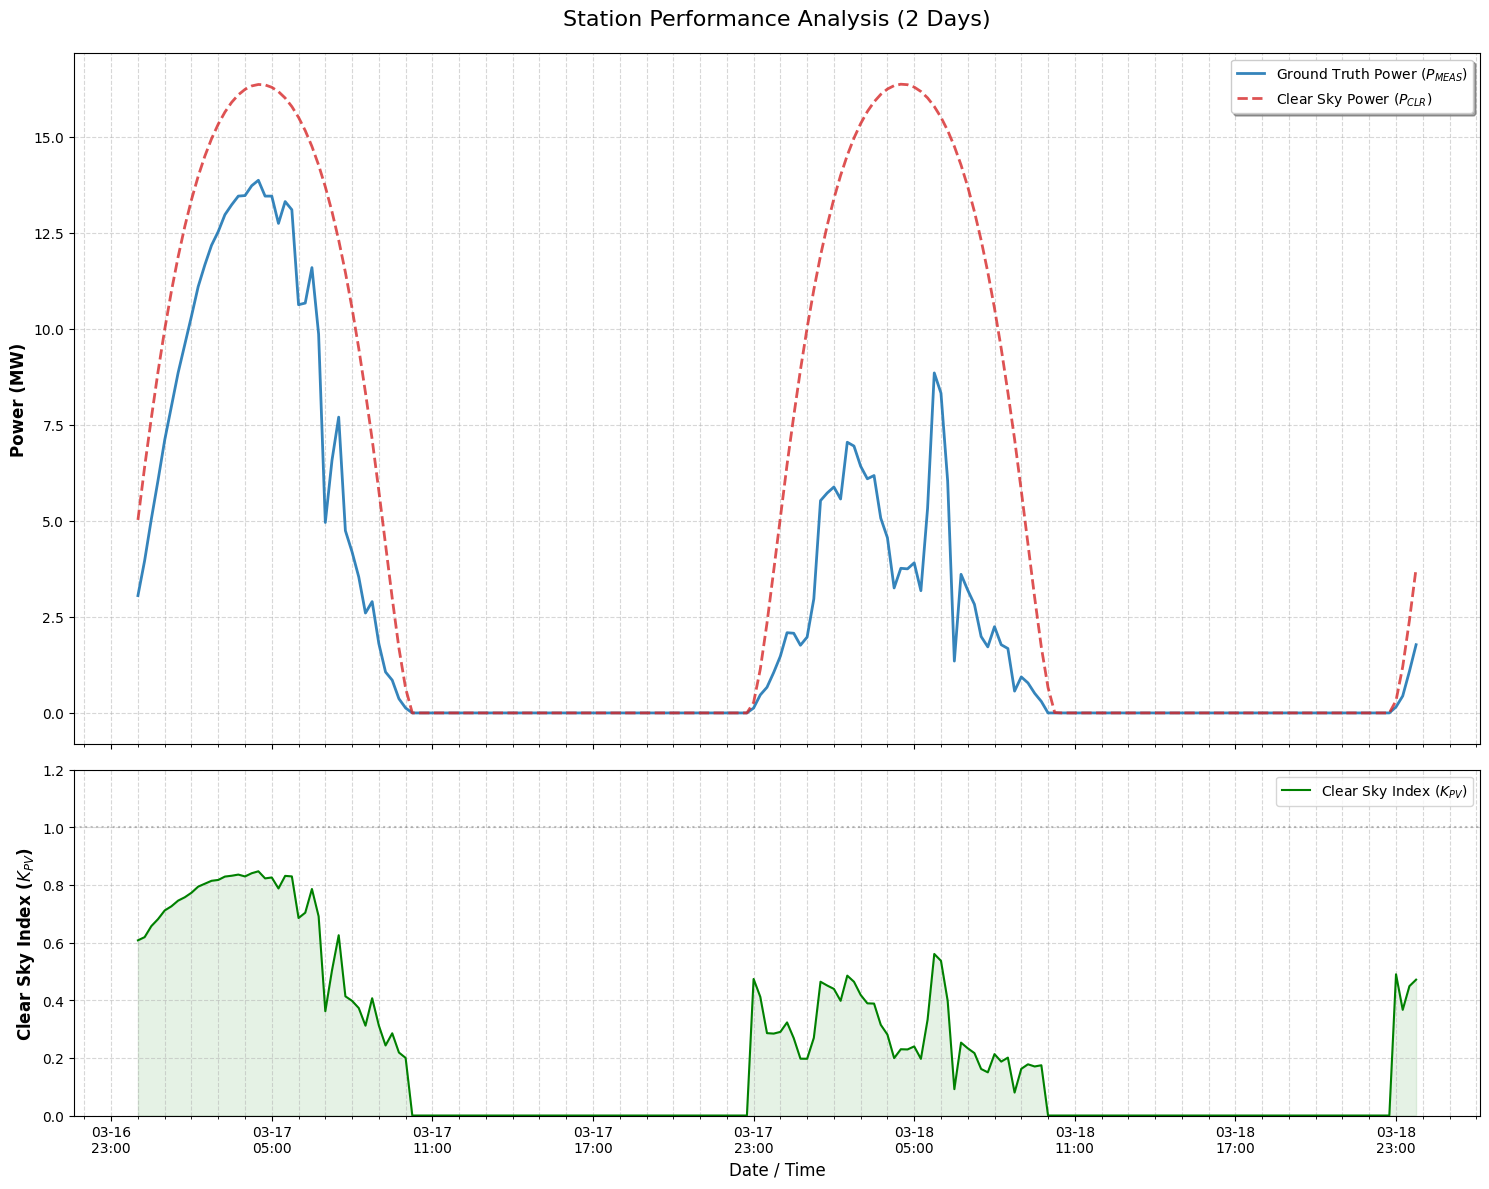

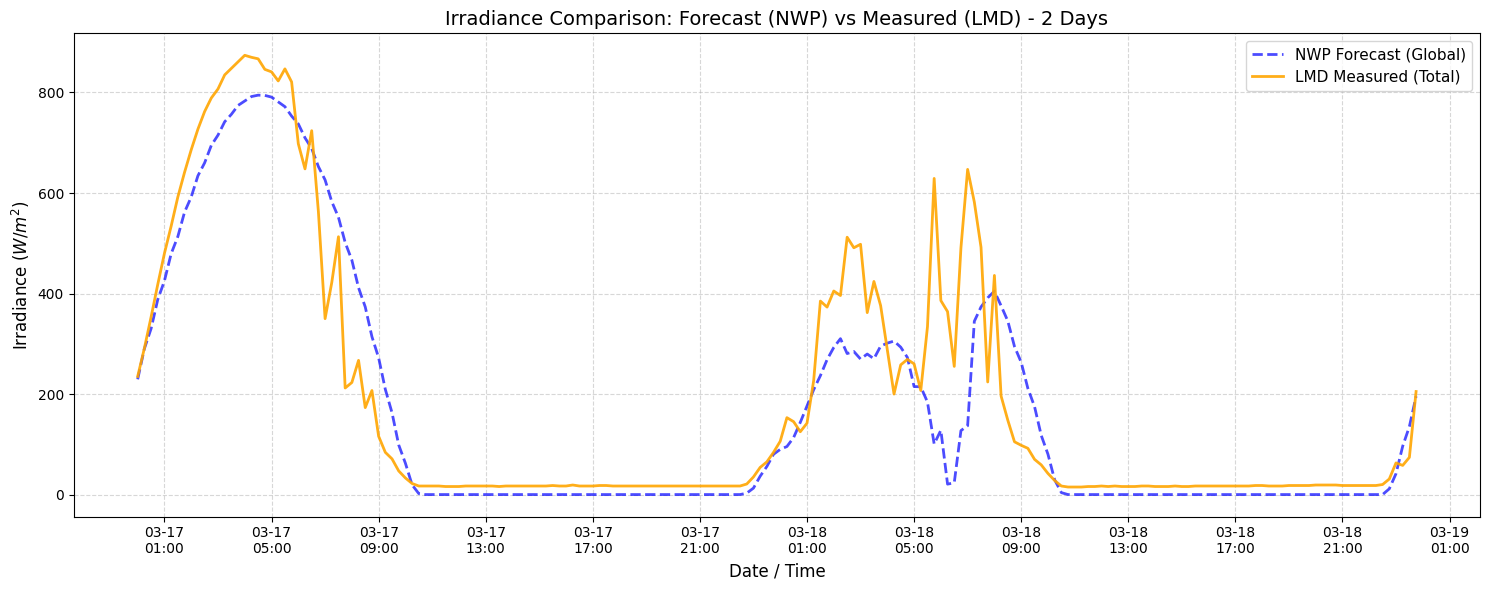

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_station_analysis(df, start_date=None, num_days=3):
    """
    Plots Power (Measured vs Clear Sky) and K_PV index on a continuous timeline.
    
    Args:
        df (pd.DataFrame): Dataframe with 'power', 'P_CLR', 'K_PV' columns and DatetimeIndex.
        start_date (str, optional): The start date (e.g., '2019-05-04'). 
                                    If None, uses the first date in the data.
        num_days (int): Number of consecutive days to plot. Default is 3.
    """
    
    # 1. Select Data Range
    # ---------------------------------------------------------
    # Ensure dataframe is sorted by date
    df = df.sort_index()
    
    # Determine Start Date
    if start_date:
        try:
            # Normalize to start of that day
            start_ts = pd.to_datetime(start_date).normalize()
        except:
            print(f"Error: Could not parse start_date '{start_date}'. Using data start.")
            start_ts = df.index[0].normalize()
    else:
        start_ts = df.index[0].normalize()
        
    # Determine End Date
    end_ts = start_ts + pd.Timedelta(days=num_days)
    
    # Slice the dataframe
    mask = (df.index >= start_ts) & (df.index < end_ts)
    plot_data = df.loc[mask]
    
    if plot_data.empty:
        print(f"No data found between {start_ts.date()} and {end_ts.date()}.")
        return

    # 2. Create Plot (2 Subplots: Power & K_PV)
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]}) # Power plot is taller
    
    plt.subplots_adjust(hspace=0.1) # Reduce gap between plots
    
    # --- Top Plot: Power (Ground Truth vs Clear Sky) ---
    ax1.set_title(f'Station Performance Analysis ({num_days} Days)', fontsize=16, pad=20)
    
    # Plot Ground Truth
    ax1.plot(plot_data.index, plot_data['power'], 
             label='Ground Truth Power ($P_{MEAS}$)', 
             color='#1f77b4', linewidth=2, alpha=0.9)
    
    # Plot Clear Sky Power
    if 'P_CLR' in plot_data.columns:
        ax1.plot(plot_data.index, plot_data['P_CLR'], 
                 label='Clear Sky Power ($P_{CLR}$)', 
                 color='#d62728', linestyle='--', linewidth=2, alpha=0.8)

    ax1.set_ylabel('Power (MW)', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', frameon=True, shadow=True)
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)
    
    # --- Bottom Plot: Clear Sky Index (K_PV) ---
    if 'K_PV' in plot_data.columns:
        ax2.plot(plot_data.index, plot_data['K_PV'], 
                 label='Clear Sky Index ($K_{PV}$)', 
                 color='green', linewidth=1.5)
        
        # Add visual guide lines for K_PV
        ax2.axhline(1.0, color='gray', linestyle=':', alpha=0.5) # Theoretical max clear sky
        ax2.fill_between(plot_data.index, plot_data['K_PV'], color='green', alpha=0.1)
    
    ax2.set_ylabel('Clear Sky Index ($K_{PV}$)', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1.2) # K_PV is usually between 0 and 1.1
    ax2.legend(loc='upper right')
    ax2.grid(True, which='both', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Date / Time', fontsize=12)

    # 3. Date Formatting
    # ---------------------------------------------------------
    # If plotting <= 3 days, show Hour:Minute. If more, focus on Days.
    if num_days <= 3:
        ax2.xaxis.set_major_locator(mdates.HourLocator(interval=6))
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
        ax2.xaxis.set_minor_locator(mdates.HourLocator(interval=1))
    else:
        ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.tight_layout()
    plt.savefig('station_analysis_plot.png')
    plt.show()

def plot_irradiance_comparison(df, start_date=None, num_days=3):
    """
    Plots Forecasted Irradiance (NWP) vs Measured Irradiance (LMD).
    
    Args:
        df (pd.DataFrame): Dataframe containing 'nwp_globalirrad' and 'lmd_totalirrad'.
        start_date (str): Start date (e.g., '2019-05-04').
        num_days (int): Number of days to plot.
    """
    
    # 1. Prepare Data
    # ---------------------------------------------------------
    # Ensure index is datetime and sorted
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'date_time' in df.columns:
            df = df.set_index('date_time')
        df.index = pd.to_datetime(df.index)
        
    df = df.sort_index()

    # Define Time Range
    if start_date:
        try:
            start_ts = pd.to_datetime(start_date).normalize()
        except:
            print(f"Error parsing date {start_date}, using first available.")
            start_ts = df.index[0].normalize()
    else:
        start_ts = df.index[0].normalize()
        
    end_ts = start_ts + pd.Timedelta(days=num_days)
    
    # Slice Data
    mask = (df.index >= start_ts) & (df.index < end_ts)
    plot_data = df.loc[mask]
    
    if plot_data.empty:
        print("No data found for the specified range.")
        return

    # 2. Plotting
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Plot NWP (Forecast) - Dashed Line
    ax.plot(plot_data.index, plot_data['nwp_globalirrad'], 
            label='NWP Forecast (Global)', 
            color='blue', linestyle='--', linewidth=2, alpha=0.7)
    
    # Plot LMD (Measurement) - Solid Line
    ax.plot(plot_data.index, plot_data['lmd_totalirrad'], 
            label='LMD Measured (Total)', 
            color='orange', linewidth=2, alpha=0.9)

    # 3. Formatting
    # ---------------------------------------------------------
    ax.set_title(f'Irradiance Comparison: Forecast (NWP) vs Measured (LMD) - {num_days} Days', fontsize=14)
    ax.set_ylabel('Irradiance ($W/m^2$)', fontsize=12)
    ax.set_xlabel('Date / Time', fontsize=12)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Date formatting on X-Axis
    if num_days <= 3:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

    plt.tight_layout()
    plt.show()



sDate = '2019-03-17'
plot_station_analysis(df_result, start_date= sDate, num_days=2)
plot_irradiance_comparison(df_result, start_date= sDate, num_days=2)



### Building Univariate dataset for the Power Clear index

In [15]:
station07_k_pv = df_result['K_PV'].values

---

In [14]:
x = np.linspace(0, 2 * np.pi, num=16)
y = np.digitize(np.sin(x), np.linspace(-1, 1, num=8))
y

array([4, 5, 7, 7, 7, 7, 6, 5, 3, 2, 1, 1, 1, 1, 3, 4])

In [15]:



# ### $sin(x)$
# **Task**: Overfit to a 8-bit quantized sin(x) from 0 - 2*Pi -- sampled 360 times.
#
#  @Note: The Feed-Forward model won't necessarily be able to fit this data (optimization is hard)
#  As a sanity check, you can try running with N_CLASSES = 2 (-1, 1) and d_model = 1...
#  this is the simplest "majority rule" experiment => gets 100% test accuracy.
#
#  @Note: RNN & S4 *should* fit this perfectly... but needs to be verified.
def create_sin_x_dataset(n_examples=1024, bsz=128):
    print("[*] Generating Toy Dataset: sin(x)...")

    # Constants
    SEQ_LENGTH, N_CLASSES, IN_DIM = 16, 8, 1
    x = np.linspace(0, 2 * np.pi, num=SEQ_LENGTH)
    y = np.digitize(np.sin(x), np.linspace(-1, 1, num=N_CLASSES))

    # Tile this `n_examples` times...
    data = torch.Tensor(
        np.tile(
            np.expand_dims(np.expand_dims(y, -1), 0), reps=[n_examples, 1, 1] # (N, 16, 1) --> (Batches, Sequence Length, Features)
        )
    )

    # Build Datasets -- Two entries to match (inputs, targets) structure
    train = TensorDataset(data, data)
    test = TensorDataset(data[:1], data[:1])

    # Return data loaders, with the provided batch size
    trainloader = torch.utils.data.DataLoader(
        train, batch_size=bsz, shuffle=True
    )
    testloader = torch.utils.data.DataLoader(
        test, batch_size=bsz, shuffle=False
    )

    return trainloader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM


# ### $sin(ax + b)$
# **Task**: Fit arbitrary 8-bit quantized functions of the form sin(ax + b) from 0 - 2*Pi -- sampled 360 times.
#
# In this dataset, `a` controls amplitude and `b` controls phase and are sampled uniformly at random in prespecified
# intervals.
def create_sin_ax_b_dataset(n_examples=20000, bsz=128):
    print("[*] Generating sin(ax + b) Dataset using PyTorch...")

    # Constants
    # Note: SEQ_LENGTH is set to 16000 based on your code, 
    # though the comments mentioned 360. Be mindful of RAM usage (approx 1.2GB).
    SEQ_LENGTH, N_CLASSES, IN_DIM = 16000, 8, 1
    A_MIN, A_MAX = 1.0, 10.0
    B_MAX = 5.0
    
    # Define the X domain (1, SEQ_LENGTH) for broadcasting
    x = torch.linspace(0, 2 * np.pi, SEQ_LENGTH).unsqueeze(0) # Shape: [1, 16000]
    
    # Define bin boundaries for quantization
    boundaries = torch.linspace(-1, 1, steps=N_CLASSES)

    def generate_batch(num_samples):
        # 1. Generate random 'a' and 'b' for the whole batch at once
        # a shape: [num_samples, 1]
        a = (A_MAX - A_MIN) * torch.rand(num_samples, 1) + A_MIN
        
        # b shape: [num_samples, 1]
        b = B_MAX * torch.rand(num_samples, 1)
        
        # 2. Compute sin(ax + b) using broadcasting
        # [N, 1] * [1, L] + [N, 1] -> [N, L]
        y_continuous = torch.sin(a * x + b)
        
        # 3. Quantize (Digitize)
        # torch.bucketize is the PyTorch equivalent of np.digitize
        y_discrete = torch.bucketize(y_continuous, boundaries)
        
        # 4. Reshape to [N, L, 1] for the model
        return y_discrete.unsqueeze(-1).float() # Convert to float for training

    # --- Generate Data ---
    print(f"\t=>> Generating {n_examples} Training Examples...")
    train_tensor = generate_batch(n_examples)
    
    print(f"\t=>> Generating {bsz} Test Examples...")
    test_tensor = generate_batch(bsz)

    # --- Build Datasets ---
    # Input and Target are identical (Autoencoder/Reconstruction setup)
    train_dataset = TensorDataset(train_tensor, train_tensor)
    test_dataset = TensorDataset(test_tensor, test_tensor)

    # --- DataLoaders ---
    trainloader = DataLoader(train_dataset, batch_size=bsz, shuffle=True)
    testloader = DataLoader(test_dataset, batch_size=bsz, shuffle=False)

    return trainloader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM



In [16]:
trainloader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_sin_x_dataset()
trainloader_absin, testloader_absin, N_CLASSES, SEQ_LENGTH_absin, IN_DIM = create_sin_ax_b_dataset()

[*] Generating Toy Dataset: sin(x)...
[*] Generating sin(ax + b) Dataset using PyTorch...
	=>> Generating 20000 Training Examples...
	=>> Generating 128 Test Examples...


In [27]:
# plot one example quatized sin wave from the trainloader
import matplotlib.pyplot as plt
trainloader

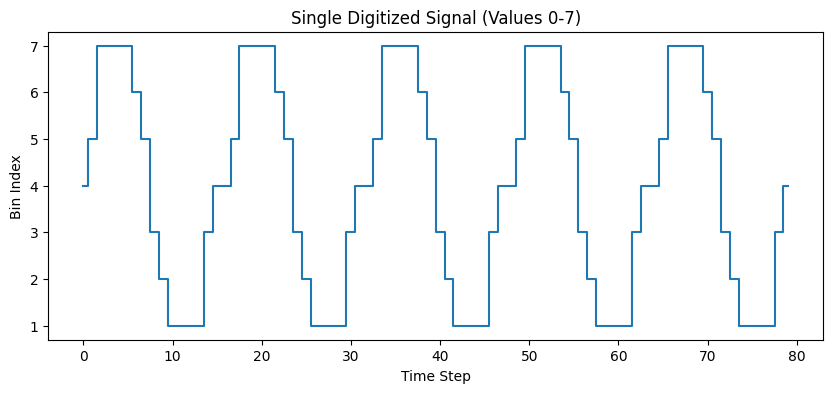

In [32]:
# Fetch one batch
for inputs, targets in trainloader:
    # Grab the first example and flatten it from (Seq_Len, 1) to (Seq_Len,)
    sine_wave = inputs[:5].flatten().numpy()
    break

# Plot
plt.figure(figsize=(10, 4))
plt.plot(sine_wave, drawstyle='steps-mid')  # 'steps' visualizes the digital nature best
plt.title(f"Single Digitized Signal (Values 0-{N_CLASSES-1})")
plt.xlabel("Time Step")
plt.ylabel("Bin Index")
plt.show()

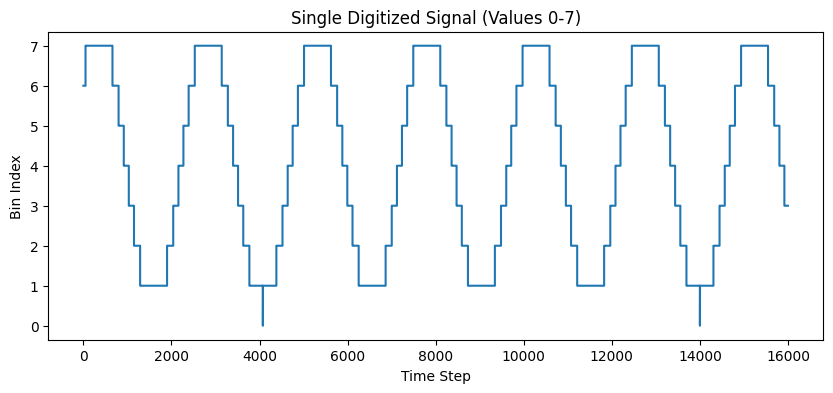

In [39]:
# Fetch one batch
for inputs, targets in trainloader_absin:
    # Grab the first example and flatten it from (Seq_Len, 1) to (Seq_Len,)
    sine_wave = inputs[2:3].flatten().numpy()
    break

# Plot
plt.figure(figsize=(10, 4))
plt.plot(sine_wave, drawstyle='steps-mid')  # 'steps' visualizes the digital nature best
plt.title(f"Single Digitized Signal (Values 0-{N_CLASSES-1})")
plt.xlabel("Time Step")
plt.ylabel("Bin Index")
plt.show()

---

### Vanilla Mamba Model to predict the K_PV. 

In [19]:
"""
Simple, minimal implementation of Mamba for Univariate Time Series Forecasting.
Adapted from the minimal language model implementation.
"""
from __future__ import annotations
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from einops import rearrange, repeat, einsum
from typing import Union
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset

# -----------------------------------------------------------------------------
# 1. Configuration & Arguments
# -----------------------------------------------------------------------------

@dataclass
class ModelArgs:
    d_model: int = 64        # Model dimension
    n_layer: int = 4         # Number of Mamba layers
    d_state: int = 16        # SSM state dimension
    expand: int = 2          # Expansion factor
    dt_rank: Union[int, str] = 'auto'
    d_conv: int = 4 
    conv_bias: bool = True
    bias: bool = False
    
    # Time Series specific
    c_in: int = 1            # Input channels (1 for univariate)
    c_out: int = 1           # Output channels (predicting power)
    
    def __post_init__(self):
        self.d_inner = int(self.expand * self.d_model)
        if self.dt_rank == 'auto':
            self.dt_rank = math.ceil(self.d_model / 16)

# -----------------------------------------------------------------------------
# 2. Mamba Model Architecture (Modified for Continuous Data)
# -----------------------------------------------------------------------------

class Mamba(nn.Module):
    def __init__(self, args: ModelArgs):
        """Full Mamba model for Time Series."""
        super().__init__()
        self.args = args
        
        # CHANGED: Replaced Embedding with Linear Projection for continuous data
        # Maps continuous scalar input -> d_model
        self.encoder = nn.Linear(args.c_in, args.d_model)
        
        self.layers = nn.ModuleList([ResidualBlock(args) for _ in range(args.n_layer)])
        self.norm_f = RMSNorm(args.d_model)

        # CHANGED: Output head projects back to scalar (1 dimension)
        self.head = nn.Linear(args.d_model, args.c_out, bias=False)

    def forward(self, x):
        """
        Args:
            x (float tensor): shape (b, l, c_in) 
        Returns:
            output: shape (b, l, c_out)
        """
        # Project continuous input to hidden dimension
        x = self.encoder(x)
        
        for layer in self.layers:
            x = layer(x)
            
        x = self.norm_f(x)
        
        # Project back to time series value
        output = self.head(x) 

        return output

class ResidualBlock(nn.Module):
    def __init__(self, args: ModelArgs):
        super().__init__()
        self.args = args
        self.mixer = MambaBlock(args)
        self.norm = RMSNorm(args.d_model)

    def forward(self, x):
        output = self.mixer(self.norm(x)) + x
        return output

class MambaBlock(nn.Module):
    def __init__(self, args: ModelArgs):
        super().__init__()
        self.args = args
        self.in_proj = nn.Linear(args.d_model, args.d_inner * 2, bias=args.bias)

        self.conv1d = nn.Conv1d(
            in_channels=args.d_inner,
            out_channels=args.d_inner,
            bias=args.conv_bias,
            kernel_size=args.d_conv,
            groups=args.d_inner,
            padding=args.d_conv - 1,
        )

        self.x_proj = nn.Linear(args.d_inner, args.dt_rank + args.d_state * 2, bias=False)
        self.dt_proj = nn.Linear(args.dt_rank, args.d_inner, bias=True)

        A = repeat(torch.arange(1, args.d_state + 1), 'n -> d n', d=args.d_inner)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(args.d_inner))
        self.out_proj = nn.Linear(args.d_inner, args.d_model, bias=args.bias)

    def forward(self, x):
        (b, l, d) = x.shape
        x_and_res = self.in_proj(x)
        (x, res) = x_and_res.split(split_size=[self.args.d_inner, self.args.d_inner], dim=-1)

        x = rearrange(x, 'b l d_in -> b d_in l')
        x = self.conv1d(x)[:, :, :l]
        x = rearrange(x, 'b d_in l -> b l d_in')
        
        x = F.silu(x)
        y = self.ssm(x)
        y = y * F.silu(res)
        output = self.out_proj(y)
        return output

    def ssm(self, x):
        (d_in, n) = self.A_log.shape
        A = -torch.exp(self.A_log.float())
        D = self.D.float()
        x_dbl = self.x_proj(x)
        (delta, B, C) = x_dbl.split(split_size=[self.args.dt_rank, n, n], dim=-1)
        delta = F.softplus(self.dt_proj(delta))
        y = self.selective_scan(x, delta, A, B, C, D)
        return y

    def selective_scan(self, u, delta, A, B, C, D):
        (b, l, d_in) = u.shape
        n = A.shape[1]
        deltaA = torch.exp(einsum(delta, A, 'b l d_in, d_in n -> b l d_in n'))
        deltaB_u = einsum(delta, B, u, 'b l d_in, b l n, b l d_in -> b l d_in n')
        
        x = torch.zeros((b, d_in, n), device=deltaA.device)
        ys = []    
        for i in range(l):
            x = deltaA[:, i] * x + deltaB_u[:, i]
            y = einsum(x, C[:, i, :], 'b d_in n, b n -> b d_in')
            ys.append(y)
        y = torch.stack(ys, dim=1)
        y = y + u * D
        return y

class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        output = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight
        return output



In [20]:
# -----------------------------------------------------------------------------
# 3. Data Loading & Generation
# -----------------------------------------------------------------------------

def generate_synthetic_power_data(days=365, interval_min=15):
    """
    Generates synthetic power usage data with daily and weekly seasonality.
    """
    total_steps = int(days * 24 * 60 / interval_min)
    t = np.linspace(0, days * 2 * np.pi, total_steps)
    
    # 1. Daily seasonality (Sine wave)
    daily = np.sin(t) 
    # 2. Weekly trend (Slower sine wave)
    weekly = 0.5 * np.sin(t / 7)
    # 3. Random noise
    noise = np.random.normal(0, 0.1, total_steps)
    # 4. Base load
    power = daily + weekly + noise + 10.0 # Shift up to be positive
    
    # Normalize to 0-1 range for stability
    power = (power - power.min()) / (power.max() - power.min())
    
    return torch.tensor(power, dtype=torch.float32).unsqueeze(-1) # Shape: (L, 1)

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        # Input: 0 to T
        x = self.data[idx : idx + self.seq_len]
        # Target: 1 to T+1 (Predict next step at every point)
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

# -----------------------------------------------------------------------------
# 4. Training & Evaluation Logic
# -----------------------------------------------------------------------------

def train_model(model, train_loader, optimizer, device, epochs=10):
    criterion = nn.MSELoss()
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            output = model(x)
            
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
        
    return losses

@torch.no_grad()
def predict_future(model, initial_sequence, future_steps, device):
    """
    Autoregressive prediction loop.
    1. Feed initial sequence.
    2. Get last prediction.
    3. Append prediction to sequence and repeat.
    """
    model.eval()
    curr_seq = initial_sequence.clone().to(device).unsqueeze(0) # (1, L, 1)
    predictions = []
    
    for _ in range(future_steps):
        output = model(curr_seq)
        
        # Get the prediction for the next time step (last element in sequence)
        next_val = output[:, -1:, :]
        predictions.append(next_val.item())
        
        # Slide window: Remove first, add prediction
        curr_seq = torch.cat([curr_seq[:, 1:, :], next_val], dim=1)
        
    return predictions



Generating synthetic data...
Starting Training on cuda...
Epoch 1/5, Loss: 0.001365
Epoch 2/5, Loss: 0.000557
Epoch 3/5, Loss: 0.000556
Epoch 4/5, Loss: 0.000557
Epoch 5/5, Loss: 0.000552
Forecasting...
Training complete. Showing plots...


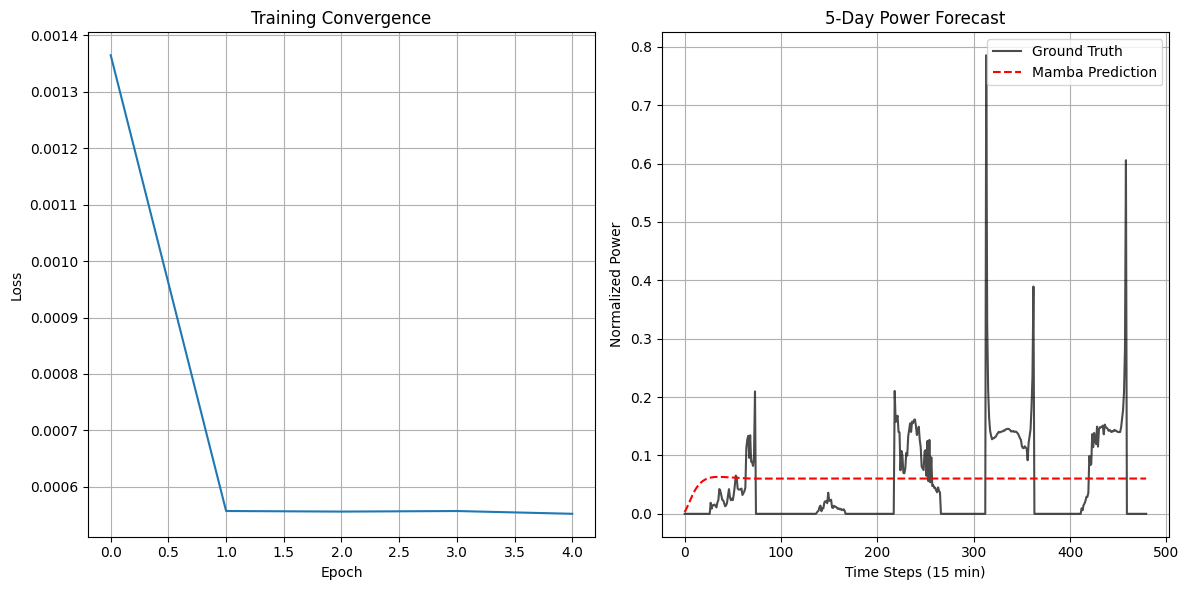

In [79]:
# -----------------------------------------------------------------------------
# 5. Main Execution
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # Settings
    SEQ_LEN = 96         # Lookback window (96 * 15min = 24 hours)
    PREDICT_DAYS = 5     # Predict 5 days ahead
    PREDICT_STEPS = PREDICT_DAYS * 96 
    BATCH_SIZE = 32
    EPOCHS = 5
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print(f"Generating synthetic data...")
    # Generate 1 year of data (15 min resolution)
    
    #full_data = generate_synthetic_power_data(days=365)
    


    power_values = df_result['K_PV'].values
        

    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    power_normalized = scaler.fit_transform(power_values.reshape(-1, 1))

    full_data = torch.tensor(power_normalized, dtype=torch.float32)
    
    # Split Train/Test (Last 7 days for testing)
    test_size = 7 * 672
    train_data = full_data[:-test_size]
    test_data = full_data[-test_size:]
    
    dataset = TimeSeriesDataset(train_data, SEQ_LEN)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize Model
    args = ModelArgs(d_model=64, n_layer=8, c_in=1)
    model = Mamba(args).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    
    print(f"Starting Training on {DEVICE}...")
    loss_history = train_model(model, train_loader, optimizer, DEVICE, epochs=EPOCHS)
    
    # --- Evaluation ---
    print("Forecasting...")
    
    # Take the last 'SEQ_LEN' points from training data to start predicting into the test set
    initial_seq = train_data[-SEQ_LEN:]
    
    # Predict N days ahead
    predicted_values = predict_future(model, initial_seq, PREDICT_STEPS, DEVICE)
    
    # Get Ground Truth for those days
    ground_truth = test_data[:PREDICT_STEPS].numpy()
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label='Training Loss (MSE)')
    plt.title('Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    # Plot 2: Forecast vs Truth
    plt.subplot(1, 2, 2)
    plt.plot(ground_truth, label='Ground Truth', color='black', alpha=0.7)
    plt.plot(predicted_values, label='Mamba Prediction', color='red', linestyle='--')
    plt.title(f'{PREDICT_DAYS}-Day Power Forecast')
    plt.xlabel('Time Steps (15 min)')
    plt.ylabel('Normalized Power')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    print("Training complete. Showing plots...")
    plt.show()


----

### Original Mamab



In [21]:
import torch
import torch.nn as nn
from mamba_ssm import Mamba # <--- The optimized CUDA version

class OptimizedMambaTimeSeries(nn.Module):
    def __init__(self, input_dim=1, output_dim=1, d_model=64, n_layers=4):
        super().__init__()
        
        # 1. ENCODER: Maps continuous value (Power) to a vector
        # Replaces 'Embedding' used in NLP
        self.encoder = nn.Linear(input_dim, d_model)
        
        # 2. BACKBONE: The stack of optimized Mamba blocks
        self.layers = nn.ModuleList([
            ResidualMambaBlock(d_model) for _ in range(n_layers)
        ])
        
        # 3. NORM & HEAD: Final prediction
        self.norm_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: (Batch, Length, 1)
        
        x = self.encoder(x) # -> (Batch, Length, d_model)
        
        for layer in self.layers:
            x = layer(x)
            
        x = self.norm_f(x)
        x = self.head(x)    # -> (Batch, Length, 1)
        
        return x

class ResidualMambaBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        # The 'Mamba' class here is the fast, CUDA-optimized one you installed
        self.mixer = Mamba(
            d_model=d_model, # Model dimension d_model
            d_state=16,      # SSM state expansion factor
            d_conv=4,        # Local convolution width
            expand=2,        # Block expansion factor
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # Standard "Pre-Norm" Residual connection
        # Output = Input + Mamba(Norm(Input))
        return x + self.mixer(self.norm(x))

Model Parameters: 262465
Epoch 1/50, Loss: 0.001845
Epoch 2/50, Loss: 0.000533
Epoch 3/50, Loss: 0.000527
Epoch 4/50, Loss: 0.000523
Epoch 5/50, Loss: 0.000513
Epoch 6/50, Loss: 0.000461
Epoch 7/50, Loss: 0.000472
Epoch 8/50, Loss: 0.000392
Epoch 9/50, Loss: 0.000362
Epoch 10/50, Loss: 0.000330
Epoch 11/50, Loss: 0.000297
Epoch 12/50, Loss: 0.000228
Epoch 13/50, Loss: 0.000206
Epoch 14/50, Loss: 0.000135
Epoch 15/50, Loss: 0.000179
Epoch 16/50, Loss: 0.000103
Epoch 17/50, Loss: 0.000140
Epoch 18/50, Loss: 0.000096
Epoch 19/50, Loss: 0.000161
Epoch 20/50, Loss: 0.000060
Epoch 21/50, Loss: 0.000066
Epoch 22/50, Loss: 0.000111
Epoch 23/50, Loss: 0.000052
Epoch 24/50, Loss: 0.000061
Epoch 25/50, Loss: 0.000064
Epoch 26/50, Loss: 0.000040
Epoch 27/50, Loss: 0.000058
Epoch 28/50, Loss: 0.000034
Epoch 29/50, Loss: 0.000047
Epoch 30/50, Loss: 0.000070
Epoch 31/50, Loss: 0.000043
Epoch 32/50, Loss: 0.000058
Epoch 33/50, Loss: 0.000043
Epoch 34/50, Loss: 0.000040
Epoch 35/50, Loss: 0.000038
Epoc

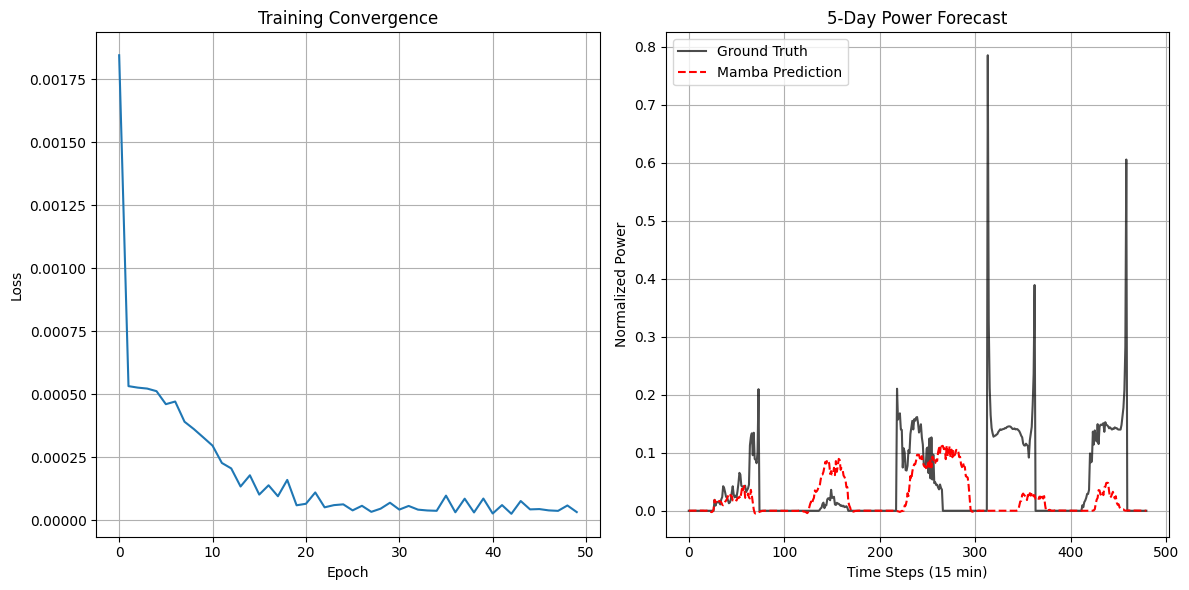

In [ ]:
if __name__ == "__main__":
    # Settings
    SEQ_LEN = 672         # Lookback window (96 * 15min = 24 hours)
    PREDICT_DAYS = 5     # Predict 5 days ahead
    PREDICT_STEPS = PREDICT_DAYS * 96 
    BATCH_SIZE = 32
    EPOCHS = 50
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Prepare Data
    # full_data = generate_synthetic_power_data(days=365) 
    power_values = df_result['K_PV'].values
        

    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    power_normalized = scaler.fit_transform(power_values.reshape(-1, 1))

    full_data = torch.tensor(power_normalized, dtype=torch.float32)

    
    dataset = TimeSeriesDataset(train_data, SEQ_LEN)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 2. Initialize the OPTIMIZED Model
    model = OptimizedMambaTimeSeries(
        input_dim=1, 
        output_dim=1, 
        d_model=64, 
        n_layers=8
    ).to(DEVICE)
    
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters())}")
    
    # 3. Train (Uses the exact same function as before)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    loss_history = train_model(model, train_loader, optimizer, DEVICE, epochs=EPOCHS)
    
    # 4. Predict
    initial_seq = train_data[-SEQ_LEN:]
    predicted_values = predict_future(model, initial_seq, PREDICT_STEPS, DEVICE)

    # Get Ground Truth for those days
    ground_truth = test_data[:PREDICT_STEPS].numpy()
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label='Training Loss (MSE)')
    plt.title('Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    # Plot 2: Forecast vs Truth
    plt.subplot(1, 2, 2)
    plt.plot(ground_truth, label='Ground Truth', color='black', alpha=0.7)
    plt.plot(predicted_values, label='Mamba Prediction', color='red', linestyle='--')
    plt.title(f'{PREDICT_DAYS}-Day Power Forecast')
    plt.xlabel('Time Steps (15 min)')
    plt.ylabel('Normalized Power')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    print("Training complete. Showing plots...")
    plt.show()




----

### LSTM Model

Using user provided DataFrame...
Initializing LSTM Model...
Starting Training on cuda...
Epoch 1/50, Loss: 0.001113
Epoch 2/50, Loss: 0.000841
Epoch 3/50, Loss: 0.000713
Epoch 4/50, Loss: 0.000632
Epoch 5/50, Loss: 0.000587
Epoch 6/50, Loss: 0.000603
Epoch 7/50, Loss: 0.000571
Epoch 8/50, Loss: 0.000531
Epoch 9/50, Loss: 0.000474
Epoch 10/50, Loss: 0.000402
Epoch 11/50, Loss: 0.000305
Epoch 12/50, Loss: 0.000257
Epoch 13/50, Loss: 0.000226
Epoch 14/50, Loss: 0.000304
Epoch 15/50, Loss: 0.000473
Epoch 16/50, Loss: 0.000503
Epoch 17/50, Loss: 0.000493
Epoch 18/50, Loss: 0.000436
Epoch 19/50, Loss: 0.000425
Epoch 20/50, Loss: 0.000294
Epoch 21/50, Loss: 0.000305
Epoch 22/50, Loss: 0.000251
Epoch 23/50, Loss: 0.000252
Epoch 24/50, Loss: 0.000309
Epoch 25/50, Loss: 0.000232
Epoch 26/50, Loss: 0.000225
Epoch 27/50, Loss: 0.000193
Epoch 28/50, Loss: 0.000371
Epoch 29/50, Loss: 0.000410
Epoch 30/50, Loss: 0.000329
Epoch 31/50, Loss: 0.000223
Epoch 32/50, Loss: 0.000146
Epoch 33/50, Loss: 0.000

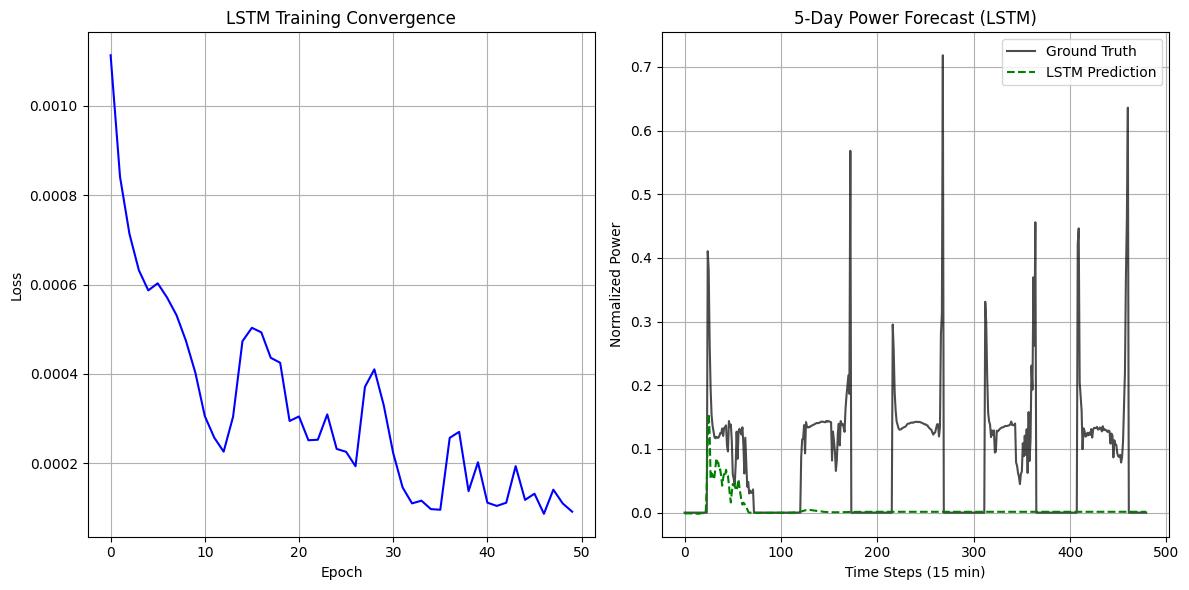

In [89]:
"""
LSTM implementation for Univariate Time Series Forecasting.
Designed to be a drop-in replacement for the Mamba comparison.
"""
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import pandas as pd # Added for the user's dataframe logic

# -----------------------------------------------------------------------------
# 1. LSTM Model Architecture
# -----------------------------------------------------------------------------

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.0):
        super().__init__()
        
        # LSTM Layer
        # batch_first=True causes input/output tensors to be of shape (batch_dim, seq_dim, feature_dim)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Linear Head to map from hidden_size to output_size (1)
        self.head = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        Args:
            x: shape (batch_size, seq_len, input_size)
        Returns:
            out: shape (batch_size, seq_len, output_size)
        """
        # LSTM returns: output, (h_n, c_n)
        # output shape: (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        
        # Pass the output of *every* time step through the linear layer
        # Linear layer automatically applies to the last dimension
        predictions = self.head(lstm_out)
        
        return predictions

# -----------------------------------------------------------------------------
# 2. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------

def generate_synthetic_power_data(days=365, interval_min=15):
    """Generates synthetic power usage data."""
    total_steps = int(days * 24 * 60 / interval_min)
    t = np.linspace(0, days * 2 * np.pi, total_steps)
    daily = np.sin(t) 
    weekly = 0.5 * np.sin(t / 7)
    noise = np.random.normal(0, 0.1, total_steps)
    power = daily + weekly + noise + 10.0
    power = (power - power.min()) / (power.max() - power.min())
    return torch.tensor(power, dtype=torch.float32).unsqueeze(-1)

class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

# -----------------------------------------------------------------------------
# 3. Training & Evaluation Logic (Same as Mamba)
# -----------------------------------------------------------------------------

def train_model(model, train_loader, optimizer, device, epochs=10):
    criterion = nn.MSELoss()
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")
        
    return losses

@torch.no_grad()
def predict_future(model, initial_sequence, future_steps, device):
    model.eval()
    curr_seq = initial_sequence.clone().to(device).unsqueeze(0)
    predictions = []
    
    for _ in range(future_steps):
        output = model(curr_seq)
        next_val = output[:, -1:, :]
        predictions.append(next_val.item())
        curr_seq = torch.cat([curr_seq[:, 1:, :], next_val], dim=1)
        
    return predictions

# -----------------------------------------------------------------------------
# 4. Main Execution
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    # Settings
    SEQ_LEN = 672         
    PREDICT_DAYS = 5     
    PREDICT_STEPS = PREDICT_DAYS * 96 
    BATCH_SIZE = 32
    EPOCHS = 50
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # -------------------------------------------------------
    # DATA LOADING SECTION
    # -------------------------------------------------------
    # Logic to switch between synthetic and your DataFrame
    
    try:
        # Assuming you have loaded your dataframe 'df_result' previously
        # This block will fail if df_result is not defined, falling back to synthetic
        if 'df_result' not in locals():
            raise NameError("df_result not defined")
            
        print("Using user provided DataFrame...")
        power_values = df_result['K_PV'].values
        
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        power_normalized = scaler.fit_transform(power_values.reshape(-1, 1))
        full_data = torch.tensor(power_normalized, dtype=torch.float32)
        
    except NameError:
        print("DataFrame not found, generating synthetic data...")
        full_data = generate_synthetic_power_data(days=365)

    # -------------------------------------------------------
    
    # Split Train/Test (Last 7 days for testing)
    # Ensure we have enough data
    test_size = 7 * 96 
    if len(full_data) < test_size + SEQ_LEN:
        # Fallback for small datasets
        test_size = int(len(full_data) * 0.2)
        
    train_data = full_data[:-test_size]
    test_data = full_data[-test_size:]
    
    dataset = TimeSeriesDataset(train_data, SEQ_LEN)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # --- LSTM Model Initialization ---
    print(f"Initializing LSTM Model...")
    model = LSTMModel(
        input_size=1, 
        hidden_size=128, 
        num_layers=4, 
        output_size=1,
        dropout=0.1
    ).to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    
    print(f"Starting Training on {DEVICE}...")
    loss_history = train_model(model, train_loader, optimizer, DEVICE, epochs=EPOCHS)
    
    # --- Evaluation ---
    print("Forecasting...")
    
    # Take the last 'SEQ_LEN' points from training data
    initial_seq = train_data[-SEQ_LEN:]
    
    # Predict N days ahead
    predicted_values = predict_future(model, initial_seq, PREDICT_STEPS, DEVICE)
    
    # Get Ground Truth (clip if test data is smaller than prediction steps)
    limit = min(len(test_data), PREDICT_STEPS)
    ground_truth = test_data[:limit].numpy()
    predicted_values = predicted_values[:limit]
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label='LSTM Training Loss (MSE)', color='blue')
    plt.title('LSTM Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    # Plot 2: Forecast vs Truth
    plt.subplot(1, 2, 2)
    plt.plot(ground_truth, label='Ground Truth', color='black', alpha=0.7)
    plt.plot(predicted_values, label='LSTM Prediction', color='green', linestyle='--')
    plt.title(f'{PREDICT_DAYS}-Day Power Forecast (LSTM)')
    plt.xlabel('Time Steps (15 min)')
    plt.ylabel('Normalized Power')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    print("Training complete. Showing plots...")
    plt.show()

-------

### Dummy Sythetic data

Initializing LSTM Model...
Starting Training on cuda...
Epoch 1/5, Loss: 0.005511
Epoch 2/5, Loss: 0.001104
Epoch 3/5, Loss: 0.001020
Epoch 4/5, Loss: 0.000981
Epoch 5/5, Loss: 0.000963
Forecasting...
Training complete. Showing plots...


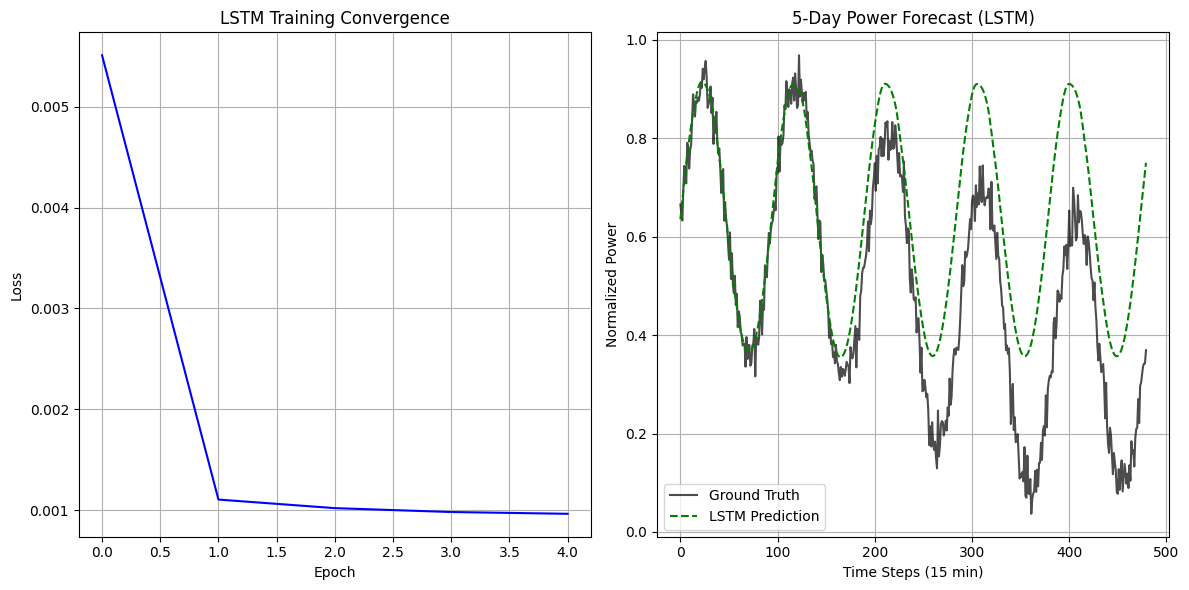

In [90]:
if __name__ == "__main__":
    # Settings
    SEQ_LEN = 672         
    PREDICT_DAYS = 5     
    PREDICT_STEPS = PREDICT_DAYS * 96 
    BATCH_SIZE = 32
    EPOCHS = 5
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # -------------------------------------------------------
    # DATA LOADING SECTION
    # -------------------------------------------------------
    # Logic to switch between synthetic and your DataFrame
    
    # try:
    #     # This block will fail if df_result is not defined, falling back to synthetic
    #     if 'df_result' not in locals():
    #         raise NameError("df_result not defined")
            
    #     print("Using user provided DataFrame...")
    #     power_values = df_result['K_PV'].values
        
    #     from sklearn.preprocessing import MinMaxScaler
    #     scaler = MinMaxScaler()
    #     power_normalized = scaler.fit_transform(power_values.reshape(-1, 1))
    #     full_data = torch.tensor(power_normalized, dtype=torch.float32)
        
    # except NameError:
    #     print("DataFrame not found, generating synthetic data...")
    
    full_data = generate_synthetic_power_data(days=365)

    # -------------------------------------------------------
    
    # Split Train/Test (Last 7 days for testing)
    # Ensure we have enough data
    test_size = 7 * 96 
    if len(full_data) < test_size + SEQ_LEN:
        # Fallback for small datasets
        test_size = int(len(full_data) * 0.2)
        
    train_data = full_data[:-test_size]
    test_data = full_data[-test_size:]
    
    dataset = TimeSeriesDataset(train_data, SEQ_LEN)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # --- LSTM Model Initialization ---
    print(f"Initializing LSTM Model...")
    model = LSTMModel(
        input_size=1, 
        hidden_size=128, 
        num_layers=4, 
        output_size=1,
        dropout=0.1
    ).to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    
    print(f"Starting Training on {DEVICE}...")
    loss_history = train_model(model, train_loader, optimizer, DEVICE, epochs=EPOCHS)
    
    # --- Evaluation ---
    print("Forecasting...")
    
    # Take the last 'SEQ_LEN' points from training data
    initial_seq = train_data[-SEQ_LEN:]
    
    # Predict N days ahead
    predicted_values = predict_future(model, initial_seq, PREDICT_STEPS, DEVICE)
    
    # Get Ground Truth (clip if test data is smaller than prediction steps)
    limit = min(len(test_data), PREDICT_STEPS)
    ground_truth = test_data[:limit].numpy()
    predicted_values = predicted_values[:limit]
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label='LSTM Training Loss (MSE)', color='blue')
    plt.title('LSTM Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    # Plot 2: Forecast vs Truth
    plt.subplot(1, 2, 2)
    plt.plot(ground_truth, label='Ground Truth', color='black', alpha=0.7)
    plt.plot(predicted_values, label='LSTM Prediction', color='green', linestyle='--')
    plt.title(f'{PREDICT_DAYS}-Day Power Forecast (LSTM)')
    plt.xlabel('Time Steps (15 min)')
    plt.ylabel('Normalized Power')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    print("Training complete. Showing plots...")
    plt.show()

Model Parameters: 262465
Epoch 1/5, Loss: 0.001672
Epoch 2/5, Loss: 0.000948
Epoch 3/5, Loss: 0.000914
Epoch 4/5, Loss: 0.000896
Epoch 5/5, Loss: 0.000883
Training complete. Showing plots...


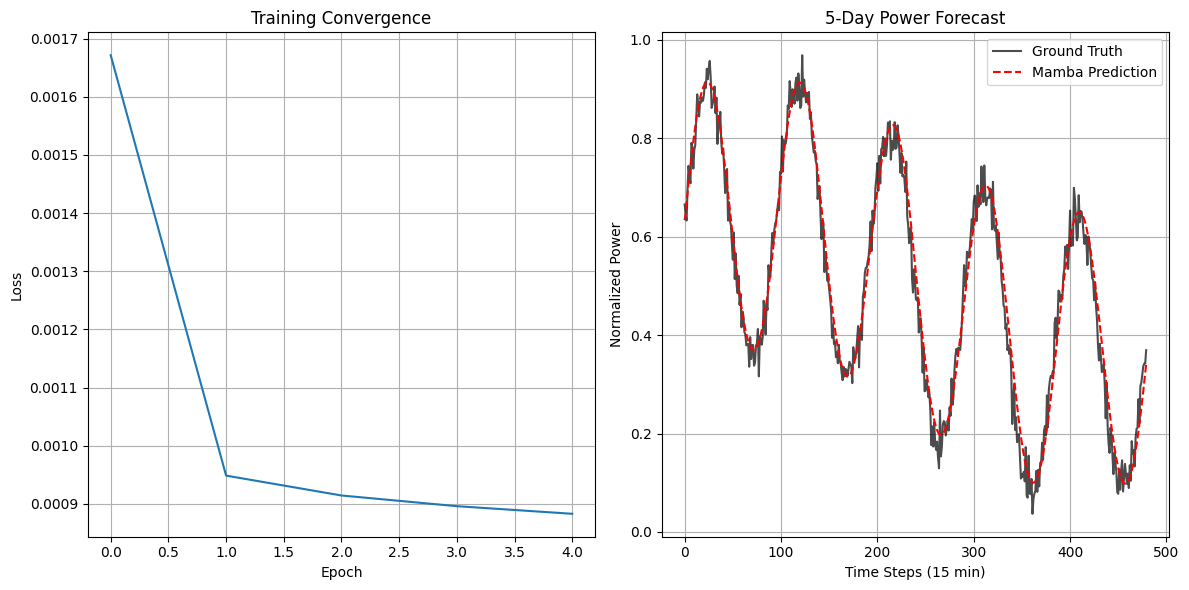

In [91]:
if __name__ == "__main__":
    # Settings
    SEQ_LEN = 672         # Lookback window (96 * 15min = 24 hours)
    PREDICT_DAYS = 5     # Predict 5 days ahead
    PREDICT_STEPS = PREDICT_DAYS * 96 
    BATCH_SIZE = 32
    EPOCHS = 5
    LR = 1e-3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Prepare Data
    full_data = generate_synthetic_power_data(days=365) 
    # power_values = df_result['K_PV'].values
        

    # from sklearn.preprocessing import MinMaxScaler
    # scaler = MinMaxScaler()
    # power_normalized = scaler.fit_transform(power_values.reshape(-1, 1))

    # full_data = torch.tensor(power_normalized, dtype=torch.float32)

    
    dataset = TimeSeriesDataset(train_data, SEQ_LEN)
    train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 2. Initialize the OPTIMIZED Model
    model = OptimizedMambaTimeSeries(
        input_dim=1, 
        output_dim=1, 
        d_model=64, 
        n_layers=8
    ).to(DEVICE)
    
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters())}")
    
    # 3. Train (Uses the exact same function as before)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    loss_history = train_model(model, train_loader, optimizer, DEVICE, epochs=EPOCHS)
    
    # 4. Predict
    initial_seq = train_data[-SEQ_LEN:]
    predicted_values = predict_future(model, initial_seq, PREDICT_STEPS, DEVICE)

    # Get Ground Truth for those days
    ground_truth = test_data[:PREDICT_STEPS].numpy()
    
    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label='Training Loss (MSE)')
    plt.title('Training Convergence')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    
    # Plot 2: Forecast vs Truth
    plt.subplot(1, 2, 2)
    plt.plot(ground_truth, label='Ground Truth', color='black', alpha=0.7)
    plt.plot(predicted_values, label='Mamba Prediction', color='red', linestyle='--')
    plt.title(f'{PREDICT_DAYS}-Day Power Forecast')
    plt.xlabel('Time Steps (15 min)')
    plt.ylabel('Normalized Power')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    print("Training complete. Showing plots...")
    plt.show()




----

## multiple features